In [7]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd().resolve()
if (root / 'src').exists():
    pass
elif (root.parent / 'src').exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from src.graph_dataset import load_elliptic_graph
from src.gnn_model import GCNClassifier
from src.model import Autoencoder

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cpu')

data, _ = load_elliptic_graph(
    features_path=str(root / 'data' / 'raw' / 'elliptic_txs_features.csv'),
    classes_path=str(root / 'data' / 'raw' / 'elliptic_txs_classes.csv'),
    edgelist_path=str(root / 'data' / 'raw' / 'elliptic_txs_edgelist.csv')
)

train_mask = (data.time_step <= 34) & (data.y != -1)
val_mask = (data.time_step >= 35) & (data.time_step <= 41) & (data.y != -1)
test_mask = (data.time_step >= 42) & (data.y != -1)

y_train = data.y[train_mask]
pos_weight = torch.tensor([1.0, (y_train == 0).sum().item() / max((y_train == 1).sum().item(), 1)], dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=pos_weight)

model = GCNClassifier(in_channels=data.num_node_features, hidden_channels=64, out_channels=2, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val = -1.0
best_state = None
patience = 8
wait = 0

for epoch in range(60):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out_val = model(data.x, data.edge_index)
        probs_val = torch.softmax(out_val[val_mask], dim=1)[:, 1].cpu().numpy()
        y_val_true = data.y[val_mask].cpu().numpy()
        val_prauc = average_precision_score(y_val_true, probs_val)

    if val_prauc > best_val + 1e-4:
        best_val = val_prauc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    out_test = model(data.x, data.edge_index)
    probs_gnn = torch.softmax(out_test[test_mask], dim=1)[:, 1].cpu().numpy()
    y_test_gnn = data.y[test_mask].cpu().numpy()

# Autoencoder baseline
proc = root / 'data' / 'processed'
X_test = np.load(proc / 'X_test.npy')
y_test_ae = np.load(proc / 'y_test.npy').astype(int)
X_val = np.load(proc / 'X_val.npy')
y_val = np.load(proc / 'y_val.npy')
import joblib
scaler = joblib.load(proc / 'scaler.joblib')

autoencoder = Autoencoder(input_dim=X_test.shape[1], bottleneck_dim=16)
autoencoder.load_state_dict(torch.load(root / 'models' / 'autoencoder_licit.pth', map_location='cpu'))
autoencoder.eval()

with torch.no_grad():
    X_test_rec = autoencoder(torch.tensor(X_test, dtype=torch.float32)).numpy()
    X_val_rec = autoencoder(torch.tensor(X_val, dtype=torch.float32)).numpy()

X_test_orig = scaler.inverse_transform(X_test)
X_val_orig = scaler.inverse_transform(X_val)
X_test_rec_orig = scaler.inverse_transform(X_test_rec)
X_val_rec_orig = scaler.inverse_transform(X_val_rec)

err_test = np.mean(np.square(X_test_orig - X_test_rec_orig), axis=1)
err_val = np.mean(np.square(X_val_orig - X_val_rec_orig), axis=1)

threshold_cfg = joblib.load(proc / 'threshold_config.joblib')
threshold = threshold_cfg.get('best_threshold', 0.5)
probs_autoencoder = -err_test
preds_autoencoder = (err_test >= threshold).astype(int)

# Alinear el tamaño de las muestras para poder comparar de forma correcta.
common_len = min(len(probs_gnn), len(probs_autoencoder))
probs_gnn = probs_gnn[:common_len]
preds_gnn = (probs_gnn >= 0.5).astype(int)
y_test_gnn = y_test_gnn[:common_len]
y_test_ae = y_test_ae[:common_len]
probs_autoencoder = probs_autoencoder[:common_len]
preds_autoencoder = preds_autoencoder[:common_len]

print('GNN test PR-AUC:', average_precision_score(y_test_gnn, probs_gnn))
print('Autoencoder test PR-AUC:', average_precision_score(y_test_ae, probs_autoencoder))
print('GNN F1:', f1_score(y_test_gnn, preds_gnn, zero_division=0))
print('Autoencoder F1:', f1_score(y_test_ae, preds_autoencoder, zero_division=0))


Cargando archivos de datos...
Grafo construido con éxito:
   - Nodos (N): 203769
   - Aristas (E): 234355
   - Dimensión de características: 165
   - Etiquetados (Lícitos/Ilícitos): 46564
   - Escalado aplicado con StandardScaler sobre train_time_step <= 34
GNN test PR-AUC: 0.20997482372863308
Autoencoder test PR-AUC: 0.33302309595289675
GNN F1: 0.22786238014664412
Autoencoder F1: 0.08261814852958005


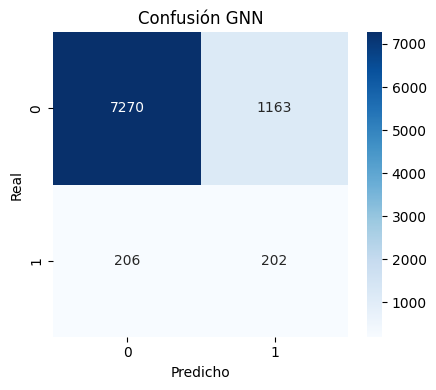

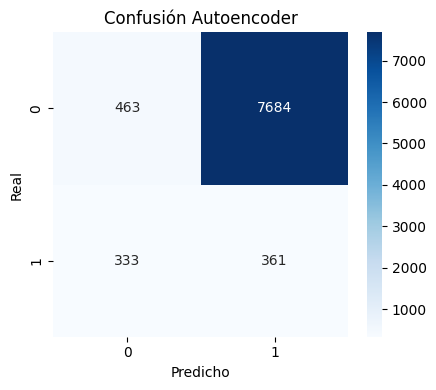

In [8]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test_gnn, preds_gnn, 'Confusión GNN')
plot_confusion_matrix(y_test_ae, preds_autoencoder, 'Confusión Autoencoder')


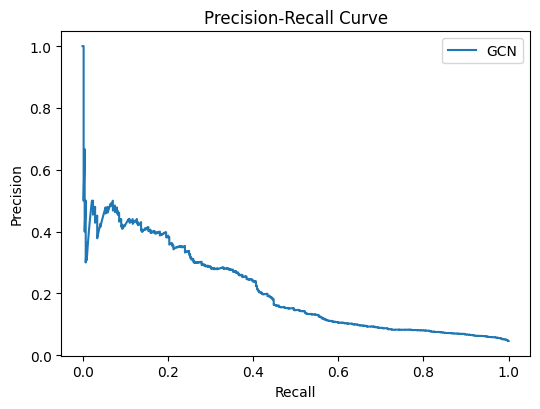

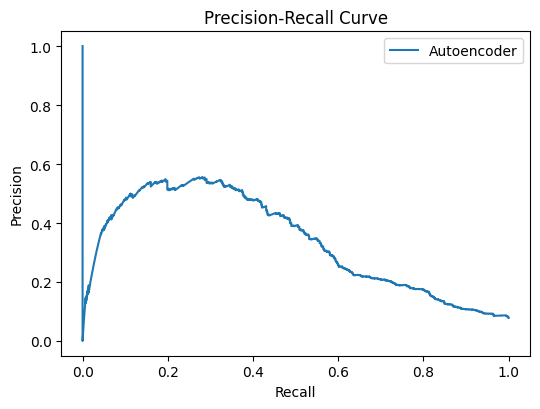

In [9]:
def plot_pr_curve(y_true, probs, label):
    precision, recall, _ = precision_recall_curve(y_true, probs)
    plt.figure(figsize=(5.5, 4.2))
    plt.plot(recall, precision, label=label)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pr_curve(y_test_gnn, probs_gnn, 'GCN')
plot_pr_curve(y_test_ae, probs_autoencoder, 'Autoencoder')


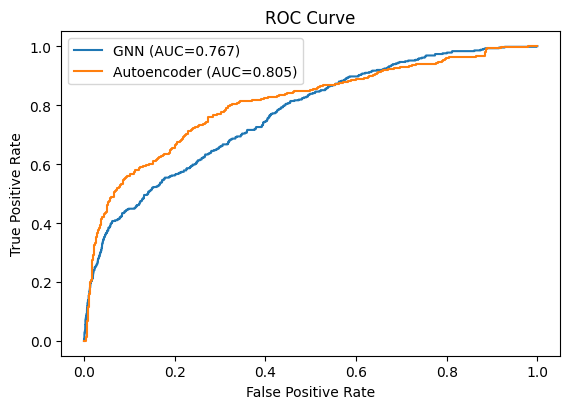

In [10]:
fpr_gnn, tpr_gnn, _ = roc_curve(y_test_gnn, probs_gnn)
fpr_ae, tpr_ae, _ = roc_curve(y_test_ae, probs_autoencoder)

plt.figure(figsize=(5.8, 4.2))
plt.plot(fpr_gnn, tpr_gnn, label=f'GNN (AUC={auc(fpr_gnn, tpr_gnn):.3f})')
plt.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC={auc(fpr_ae, tpr_ae):.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
metrics = [
    ('GNN', average_precision_score(y_test_gnn, probs_gnn), f1_score(y_test_gnn, preds_gnn, zero_division=0)),
    ('Autoencoder', average_precision_score(y_test_ae, probs_autoencoder), f1_score(y_test_ae, preds_autoencoder, zero_division=0))
]
for name, pr_auc, f1 in metrics:
    print(name, 'PR-AUC=', round(pr_auc, 4), 'F1=', round(f1, 4))


GNN PR-AUC= 0.21 F1= 0.2279
Autoencoder PR-AUC= 0.333 F1= 0.0826
